libaraies

In [25]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [26]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [27]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [28]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [29]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [30]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [31]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [32]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [33]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [34]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout or whole trial ie sniff_start = trial_start and sniff_end = trial_end.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 seconds corresponds to 12 Hz

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [35]:
def extract_subject_face_sniffs(df):
    """
    Filters BORIS dataframe for facial sniffing initiated by the subject.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Filter for subject-initiated facial sniffing
    subject_mask = df['Subject'].str.lower() == 'subject'
    sniff_mask = df['Behavior'].str.lower() == 'facial sniffing'

    return df[subject_mask & sniff_mask]



ONE SUBJECT 3.6 WORKED

In [36]:
subject_sniffs = extract_subject_face_sniffs(RI2_3_6_boris)

print("\n🔍 Subject-Initiated Facial Sniffs (RI2_3_6):")
print(subject_sniffs[['Subject', 'Behavior', 'Start (s)', 'Stop (s)']])



🔍 Subject-Initiated Facial Sniffs (RI2_3_6):
    Subject         Behavior  Start (s)  Stop (s)
0   subject  facial sniffing      4.833     4.967
1   subject  facial sniffing      5.433     5.600
2   subject  facial sniffing      8.300     8.533
5   subject  facial sniffing     14.333    14.567
6   subject  facial sniffing     17.833    20.200
7   subject  facial sniffing     20.733    20.900
9   subject  facial sniffing     21.200    22.233
11  subject  facial sniffing     25.500    26.167
16  subject  facial sniffing     32.800    33.333
17  subject  facial sniffing     33.633    34.767
20  subject  facial sniffing     42.000    42.167
21  subject  facial sniffing     44.000    44.267
24  subject  facial sniffing     68.800    70.200
34  subject  facial sniffing     87.867    88.300
35  subject  facial sniffing     91.867    92.233
38  subject  facial sniffing    125.167   125.333
44  subject  facial sniffing    195.533   195.667


RUN LOOP ON ALL SUBJECTS WORKS

In [37]:
all_subject_sniffs = []

for label, boris_df in ri1_boris_data.items():
    subject_sniffs = extract_subject_face_sniffs(boris_df)
    subject_sniffs["Trial"] = label
    subject_sniffs["Group"] = "RI1"
    all_subject_sniffs.append(subject_sniffs)

for label, boris_df in ri2_boris_data.items():
    subject_sniffs = extract_subject_face_sniffs(boris_df)
    subject_sniffs["Trial"] = label
    subject_sniffs["Group"] = "RI2"
    all_subject_sniffs.append(subject_sniffs)

combined_subject_sniffs_df = pd.concat(all_subject_sniffs, ignore_index=True)



In [38]:
combined_subject_sniffs_df

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Trial,Group,Media file,Total length,FPS,Modifiers
0,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,facial sniffing,Not defined,STATE,11.966,13.000,1.034,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,347.0,377.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,facial sniffing,Not defined,STATE,107.655,109.207,1.552,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,3122.0,3167.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
2,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,facial sniffing,Not defined,STATE,368.517,369.000,0.483,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,10688.0,10702.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
3,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,facial sniffing,Not defined,STATE,24.100,25.333,1.233,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,723.0,760.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
4,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,facial sniffing,Not defined,STATE,26.100,27.567,1.467,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,783.0,827.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
5,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,facial sniffing,Not defined,STATE,52.067,52.433,0.366,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,1562.0,1573.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
6,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,facial sniffing,Not defined,STATE,60.567,62.200,1.633,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,1817.0,1866.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
7,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,facial sniffing,Not defined,STATE,66.767,67.300,0.533,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,2003.0,2019.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
8,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,facial sniffing,Not defined,STATE,69.067,69.667,0.600,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,2072.0,2090.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
9,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29

In [39]:
ri_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    # Get full duration
    sniff_start = time[0]
    sniff_end = time[-1]

    # Compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    # Get valence
    valence = 'RI1' if trial.startswith('RI1') else ('RI2' if trial.startswith('RI2') else 'Other')

    # Extract subject as 3.6 from RI1_3_6
    try:
        parts = trial.split('_')
        subject = f"{parts[1]}.{parts[2]}"
    except IndexError:
        subject = 'Unknown'

    ri_session_rates.append({
        'Trial': trial,
        'Valence': valence,
        'Subject': subject,
        'Respiration Rate (Hz)': rate
    })

# Convert to DataFrame
ri_session_df = pd.DataFrame(ri_session_rates)
print(ri_session_df.head())


     Trial Valence Subject  Respiration Rate (Hz)
0  RI1_3_6     RI1     3.6               7.270376
1  RI2_3_6     RI2     3.6               5.932787
2  RI1_4_7     RI1     4.7               7.564174
3  RI2_4_7     RI2     4.7               6.551133
4  RI1_2_3     RI1     2.3               7.285965


In [40]:
ri_session_df

,Trial,Valence,Subject,Respiration Rate (Hz)
0,RI1_3_6,RI1,3.6,7.270376
1,RI2_3_6,RI2,3.6,5.932787
2,RI1_4_7,RI1,4.7,7.564174
3,RI2_4_7,RI2,4.7,6.551133
4,RI1_2_3,RI1,2.3,7.285965
5,RI2_2_3,RI2,2.3,6.674327
6,RI1_4_8,RI1,4.8,7.410347
7,RI2_4_8,RI2,4.8,5.775575
8,RI1_1_1,RI1,1.1,7.433281
9,RI2_1_1,RI2,1.1,6.008697


 # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)

In [41]:
def calculate_subject_sniff_resp_change(signal, time, sniff_start, sampling_rate=100, plot=True,
                                        baseline_color='gray', sniff_color='black', title=None):
    """
    Calculates % change in respiration rate (Hz) around a subject-initiated sniff event.

    Time Windows:
    - Baseline: -5s to -1s before sniff_start (4 seconds)
    - Sniff:    0s to +0.5s after sniff_start (0.5 seconds)

    Args:
        signal (np.array): respiration signal array
        time (np.array): corresponding time array
        sniff_start (float): timestamp of sniff onset (seconds)
        sampling_rate (int): sampling rate in Hz
        plot (bool): whether to show the bar plot
        baseline_color (str): color of baseline bar
        sniff_color (str): color of sniff bar
        title (str): optional custom plot title

    Returns:
        percent_change (float): % change from baseline to sniff
        baseline_mean_rate (float): mean baseline respiration rate (Hz)
        sniff_mean_rate (float): mean sniff window respiration rate (Hz)
    """
    # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]

    # Peak detection settings
    min_distance_samples = int(0.0833 * sampling_rate)  # 75 ms minimum spacing

    # Find breath peaks
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)

    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]

    # Calculate instantaneous breathing rates (1 / IBI)
    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)

    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0:
        if plot:
            print("⚠️ Not enough peaks detected in one or both windows.")
        return None, None, None

    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis

    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)

    percent_change = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    if plot:
        plt.figure(figsize=(5, 4))
        plt.bar(['Baseline', 'Subject Sniff'], 
                [baseline_mean_rate, sniff_mean_rate],
                color=[baseline_color, sniff_color])
        plt.ylabel('Respiration Rate (Hz)')
        if title:
            plt.title(title)
        else:
            plt.title(f'Subject Sniff Resp Change\n% Increase: {percent_change:.2f}%')
        plt.tight_layout()
        plt.show()

    return percent_change, baseline_mean_rate, sniff_mean_rate


In [42]:
subject_sniff_results = []

for i, sniff_row in combined_subject_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Fetch respiration signal for this trial
    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"⚠️ Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    # Calculate respiration rate change for subject-initiated sniff
    percent_change, baseline_rate, sniff_rate = calculate_subject_sniff_resp_change(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if percent_change is None:
        print(f"⚠️ Not enough peaks for sniff at {sniff_start}s in {trial}, skipping...")
        continue

    subject_sniff_results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change": percent_change,
        "Baseline Rate": baseline_rate,
        "Sniff Rate": sniff_rate
    })

# Convert to DataFrame
subject_sniff_df = pd.DataFrame(subject_sniff_results)
print(subject_sniff_df.head())


⚠️ Not enough peaks for sniff at 105.233s in RI1_1_2, skipping...
     Trial  Sniff Start  Percent Change  Baseline Rate  Sniff Rate
0  RI1_3_6       11.966       44.100005       8.192613   11.805556
1  RI1_3_6      107.655      -14.156177      10.001720    8.585859
2  RI1_3_6      368.517       -1.434961       9.684422    9.545455
3  RI1_4_7       24.100       -3.632479      10.665188   10.277778
4  RI1_4_7       26.100       -2.706748      10.382025   10.101010


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24944\1866532573.py:45: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


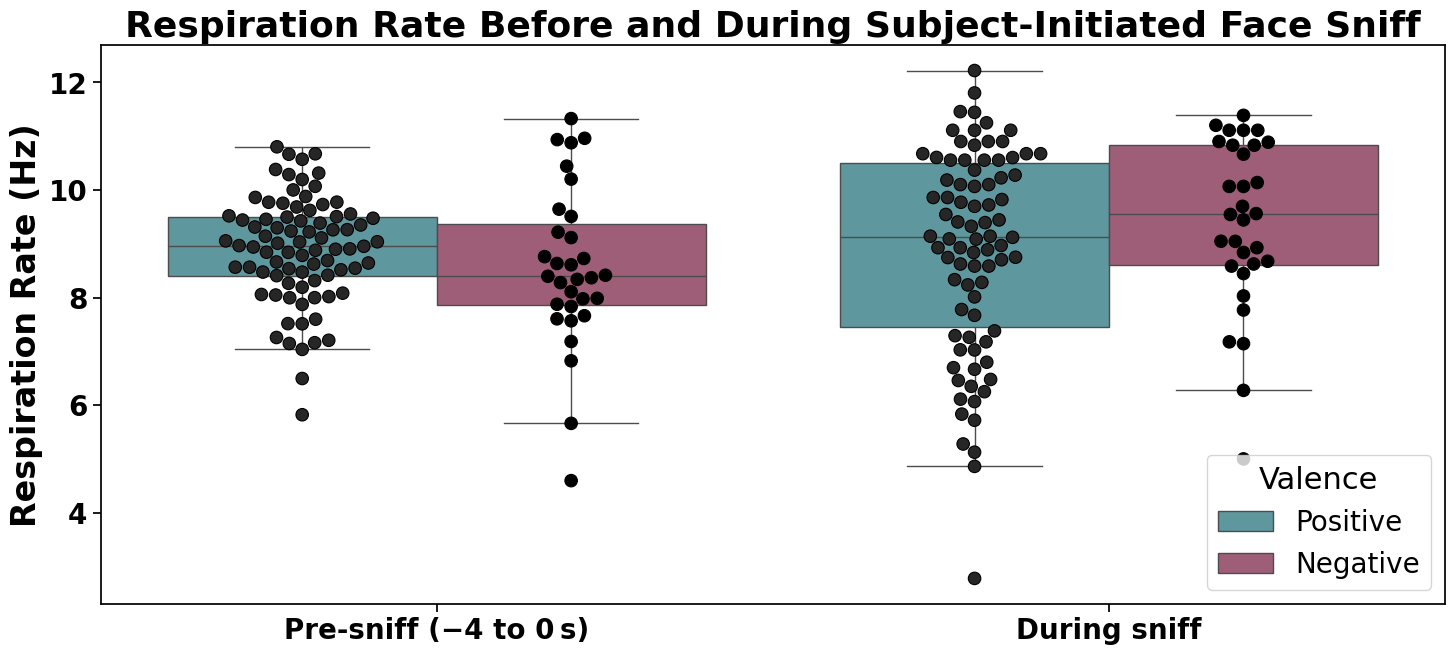

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette for valence
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Add 'Valence' column based on Trial name
subject_sniff_df['Valence'] = subject_sniff_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
subject_sniff_df = subject_sniff_df[subject_sniff_df['Valence'] != 'Unknown']

# Reshape for plotting
plot_df = subject_sniff_df.melt(
    id_vars=["Trial", "Sniff Start", "Valence"],
    value_vars=["Baseline Rate", "Sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename condition labels
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−4 to 0 s)",
    "Sniff Rate": "During sniff"
})

# Set up the plot
plt.figure(figsize=(15, 7))
sns.set_context("notebook", font_scale=1.8)

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=9,
    marker='o',
    linewidth=0.8,
    legend=False  # prevent duplicate legend
)

# Labels and formatting
plt.title("Respiration Rate Before and During Subject-Initiated Face Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=24, weight='bold')
plt.xlabel('', fontsize=22)
plt.xticks(fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')

# Legend in bottom right
plt.legend(title='Valence', fontsize=20, title_fontsize=22, loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()


NEW BASELINE AFTER SNIFF

In [44]:
def calculate_subject_face_sniff_resp_change(signal, time, sniff_start, sampling_rate=100, plot=True,
                                             baseline_color='gray', sniff_color='black', post_color='blue',
                                             title=None):
    """
    Calculates % change in respiration rate (Hz) during and after a subject-initiated face sniff.

    Time Windows:
    - Baseline:    −5 to −1 s before sniff
    - Sniff:       0 to +0.5 s
    - Post-sniff:  +0.5 to +1.5 s

    Returns:
        dict with baseline, sniff, post-sniff rates and % changes
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import find_peaks

    # Masks
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]
    post_segment = signal[post_mask]

    min_distance = int(0.0833 * sampling_rate)

    # Peaks
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance)
    post_peaks, _ = find_peaks(post_segment, distance=min_distance)

    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]
    post_peak_times = time[post_mask][post_peaks]

    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)
    post_ibis = np.diff(post_peak_times)

    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0 or len(post_ibis) == 0:
        if plot:
            print("⚠️ Not enough peaks in one or more windows.")
        return None

    baseline_rate = np.mean(1 / baseline_ibis)
    sniff_rate = np.mean(1 / sniff_ibis)
    post_rate = np.mean(1 / post_ibis)

    change_during = ((sniff_rate - baseline_rate) / baseline_rate) * 100
    change_post = ((post_rate - baseline_rate) / baseline_rate) * 100

    if plot:
        plt.figure(figsize=(6, 4))
        plt.bar(['Baseline', 'Sniff', 'Post-sniff'],
                [baseline_rate, sniff_rate, post_rate],
                color=[baseline_color, sniff_color, post_color])
        plt.ylabel('Respiration Rate (Hz)')
        plt.title(title or f'Subject Face Sniff: Δ during = {change_during:.1f}%, Δ post = {change_post:.1f}%')
        plt.tight_layout()
        plt.show()

    return {
        'Baseline Rate': baseline_rate,
        'Sniff Rate': sniff_rate,
        'Post-sniff Rate': post_rate,
        '% Change During': change_during,
        '% Change Post': change_post
    }


In [45]:
subject_face_sniff_results = []

for i, sniff_row in combined_subject_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Get respiration data
    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"⚠️ Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    result = calculate_subject_face_sniff_resp_change(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if result is None:
        print(f"⚠️ Insufficient peaks at {sniff_start}s in {trial}, skipping...")
        continue

    subject_face_sniff_results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Baseline Rate": result["Baseline Rate"],
        "Sniff Rate": result["Sniff Rate"],
        "Post-sniff Rate": result["Post-sniff Rate"],
        "% Change During": result["% Change During"],
        "% Change Post": result["% Change Post"]
    })

# Convert to DataFrame
subject_face_sniff_df = pd.DataFrame(subject_face_sniff_results)
print(subject_face_sniff_df.head())


⚠️ Insufficient peaks at 105.233s in RI1_1_2, skipping...
     Trial  Sniff Start  Baseline Rate  Sniff Rate  Post-sniff Rate  \
0  RI1_3_6       11.966       8.192613   11.805556        10.415264   
1  RI1_3_6      107.655      10.001720    8.585859        11.186869   
2  RI1_3_6      368.517       9.684422    9.545455         9.683129   
3  RI1_4_7       24.100      10.665188   10.277778         9.945887   
4  RI1_4_7       26.100      10.382025   10.101010         9.190341   

   % Change During  % Change Post  
0        44.100005      27.129939  
1       -14.156177      11.849451  
2        -1.434961      -0.013349  
3        -3.632479      -6.744382  
4        -2.706748     -11.478343  


C:\Users\sjs93\AppData\Local\Temp\ipykernel_24944\3670313292.py:46: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


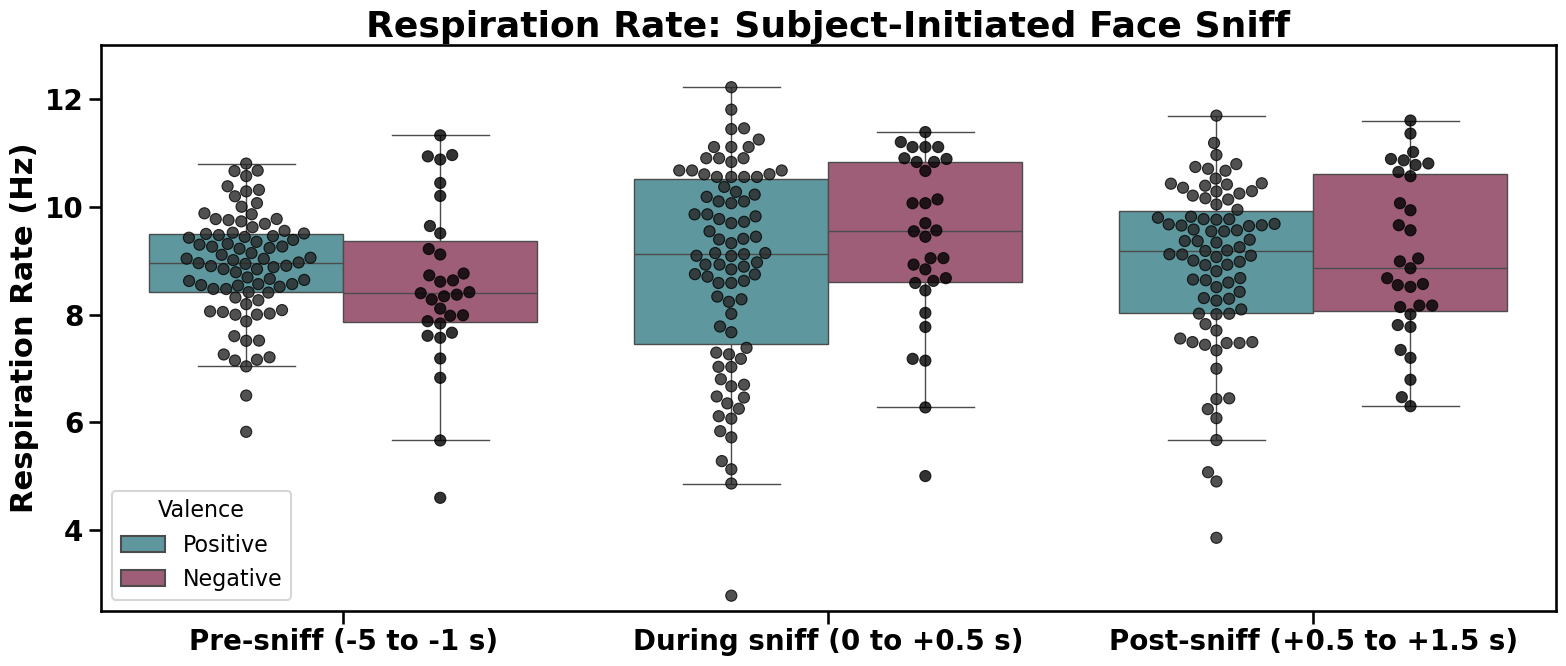

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Add valence column
subject_face_sniff_df['Valence'] = subject_face_sniff_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
subject_face_sniff_df = subject_face_sniff_df[subject_face_sniff_df['Valence'] != 'Unknown']

# Melt DataFrame to long format for plotting
plot_df = subject_face_sniff_df.melt(
    id_vars=["Trial", "Valence"],
    value_vars=["Baseline Rate", "Sniff Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for clarity
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (-5 to -1 s)",
    "Sniff Rate": "During sniff (0 to +0.5 s)",
    "Post-sniff Rate": "Post-sniff (+0.5 to +1.5 s)"
})

# Plot
plt.figure(figsize=(16, 7))
sns.set_context("talk")

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=0.8,
    size=8,
    marker='o',
    linewidth=0.8,
    legend=False
)

plt.title("Respiration Rate: Subject-Initiated Face Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=22, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=20, weight='bold')
plt.yticks(ticks=[4, 6, 8, 10, 12],fontsize=20, weight='bold')
plt.ylim(2.5, 13)

plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()


In [52]:
from scipy.stats import wilcoxon

# Prepare dataframe filtered for known valence
df = subject_face_sniff_df[subject_face_sniff_df['Valence'] != 'Unknown'].copy()

# Baseline vs During sniff
stat_during, p_during = wilcoxon(df['Baseline Rate'], df['Sniff Rate'])
print(f"Wilcoxon test Baseline vs During sniff: stat={stat_during:.3f}, p={p_during:.4f}")

# Baseline vs Post-sniff
stat_post, p_post = wilcoxon(df['Baseline Rate'], df['Post-sniff Rate'])
print(f"Wilcoxon test Baseline vs Post-sniff: stat={stat_post:.3f}, p={p_post:.4f}")


Wilcoxon test Baseline vs During sniff: stat=2682.000, p=0.1229
Wilcoxon test Baseline vs Post-sniff: stat=2787.000, p=0.2143


In [59]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Filter out Unknown valence
df = subject_face_sniff_df[subject_face_sniff_df['Valence'] != 'Unknown'].copy()

# Run Wilcoxon tests
stat_during, p_during = wilcoxon(df['Baseline Rate'], df['Sniff Rate'])
stat_post, p_post = wilcoxon(df['Baseline Rate'], df['Post-sniff Rate'])

# Collect raw p-values
raw_pvals = [p_during, p_post]
labels = ["Baseline vs During Sniff", "Baseline vs Post-sniff"]

# Apply multiple comparison correction
fdr_corrected = multipletests(raw_pvals, method='fdr_bh')
bonf_corrected = multipletests(raw_pvals, method='bonferroni')

# Report
print("\n📊 Wilcoxon Tests with Corrections:\n")
for i, label in enumerate(labels):
    print(f"{label}:")
    print(f"  Raw p = {raw_pvals[i]:.4f}")
    print(f"  FDR-corrected p = {fdr_corrected[1][i]:.4f}")
    print(f"  Bonferroni-corrected p = {bonf_corrected[1][i]:.4f}\n")



📊 Wilcoxon Tests with Corrections:

Baseline vs During Sniff:
  Raw p = 0.1229
  FDR-corrected p = 0.2143
  Bonferroni-corrected p = 0.2458

Baseline vs Post-sniff:
  Raw p = 0.2143
  FDR-corrected p = 0.2143
  Bonferroni-corrected p = 0.4285



In [63]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Filter to include only known valence
df = subject_face_sniff_df[subject_face_sniff_df['Valence'].isin(['Positive', 'Negative'])].copy()

# Separate by valence
pos = df[df["Valence"] == "Positive"]
neg = df[df["Valence"] == "Negative"]

# Mann–Whitney U tests
pvals = []

# Pre-sniff
_, p_pre = mannwhitneyu(pos["Baseline Rate"], neg["Baseline Rate"], alternative='two-sided')
pvals.append(p_pre)

# During sniff
_, p_during = mannwhitneyu(pos["Sniff Rate"], neg["Sniff Rate"], alternative='two-sided')
pvals.append(p_during)

# Post-sniff
_, p_post = mannwhitneyu(pos["Post-sniff Rate"], neg["Post-sniff Rate"], alternative='two-sided')
pvals.append(p_post)

# Multiple comparisons correction
reject_fdr, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
reject_bonf, pvals_bonf, _, _ = multipletests(pvals, method="bonferroni")

# Report
print("📊 Mann–Whitney U Tests (Negative vs Positive, Subject-Initiated Face Sniff):")

labels = ["Pre-sniff", "During sniff", "Post-sniff"]
for i, label in enumerate(labels):
    print(f"{label}: Raw p = {pvals[i]:.4f}, FDR = {pvals_fdr[i]:.4f}, Bonferroni = {pvals_bonf[i]:.4f}")


📊 Mann–Whitney U Tests (Negative vs Positive, Subject-Initiated Face Sniff):
Pre-sniff: Raw p = 0.1127, FDR = 0.3381, Bonferroni = 0.3381
During sniff: Raw p = 0.2670, FDR = 0.4005, Bonferroni = 0.8009
Post-sniff: Raw p = 0.8193, FDR = 0.8193, Bonferroni = 1.0000
